In [1]:
import os
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score
)

In [2]:
from google.colab import drive

drive.mount('/content/drive')

base_path = (
    '/content/drive/MyDrive/'
    'dissertation_project/data'
)

processed_path = (
    f'{base_path}/processed'
)

print(
    "Processed path:",
    processed_path
)

Mounted at /content/drive
Processed path: /content/drive/MyDrive/dissertation_project/data/processed


In [3]:
fusion_file = (
    f'{processed_path}/'
    'fusion_features_layer1.csv'
)

fusion_df = pd.read_csv(
    fusion_file
)

print(
    "Fusion feature shape:",
    fusion_df.shape
)

display(
    fusion_df.head()
)

Fusion feature shape: (1513, 129)


,study_id,fusion_feature_0,fusion_feature_1,fusion_feature_2,fusion_feature_3,fusion_feature_4,fusion_feature_5,fusion_feature_6,fusion_feature_7,fusion_feature_8,...,fusion_feature_118,fusion_feature_119,fusion_feature_120,fusion_feature_121,fusion_feature_122,fusion_feature_123,fusion_feature_124,fusion_feature_125,fusion_feature_126,fusion_feature_127
0,58630288,0.000000,0.0,0.0,20.240543,0.0,0.0,0.0,0.0,209.73631,...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,35.595055,0.0,240.43594
1,58239923,0.000000,0.0,0.0,44.328487,0.0,0.0,0.0,0.0,248.49486,...,0.000000,0.000000,0.0,0.0,0.000000,0.945898,0.0,13.081628,0.0,276.55440
2,53321493,0.000000,0.0,0.0,23.440650,0.0,0.0,0.0,0.0,225.65085,...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,43.213104,0.0,214.85527
3,56501836,16.122736,0.0,0.0,4.782885,0.0,0.0,0.0,0.0,0.00000,...,1.075445,46.294983,0.0,0.0,38.785873,0.000000,0.0,23.156618,0.0,0.00000
4,50650870,0.000000,0.0,0.0,40.734177,0.0,0.0,0.0,0.0,229.50403,...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,17.085352,0.0,243.49706


In [4]:
X_full = (
    fusion_df
    .select_dtypes(
        include=[np.number]
    )
    .copy()
)

print(
    "Numeric fusion features:",
    X_full.shape
)

Numeric fusion features: (1513, 129)


In [5]:
# test data

calibration_file = (
    f'{processed_path}/'
    'test_calibration_pool.csv'
)

clinical_df = pd.read_csv(
    calibration_file
)

print(
    "Clinical data shape:",
    clinical_df.shape
)

print(
    "Available target columns:"
)

print(
    [
        col
        for col in clinical_df.columns
        if 'Pleural' in col
    ]
)

Clinical data shape: (687, 69)
Available target columns:
['Pleural Effusion']


In [6]:
TARGET_LABEL = 'Pleural Effusion'

y = (
    clinical_df[
        TARGET_LABEL
    ]
    .fillna(0)
    .replace(-1, 0)
    .astype(int)
    .values
)

n = min(
    len(X_full),
    len(y)
)

X_full = X_full.iloc[
    :n
].values

y = y[
    :n
]

print(
    "Records used:",
    n
)

print(
    "X shape:",
    X_full.shape
)

print(
    "y shape:",
    y.shape
)

Records used: 687
X shape: (687, 129)
y shape: (687,)


In [7]:
print(
    "Total fusion dimensions:",
    X_full.shape[1]
)

Total fusion dimensions: 129


In [8]:
total_features = X_full.shape[1]

block_size = (
    total_features // 3
)

print(
    "Approximate block size:",
    block_size
)

Approximate block size: 43


In [9]:
# multimodal representation

X_image_removed = (
    X_full.copy()
)

X_text_removed = (
    X_full.copy()
)

X_structured_removed = (
    X_full.copy()
)

# Remove image block
X_image_removed[
    :,
    :block_size
] = 0

# Remove text block
X_text_removed[
    :,
    block_size:2 * block_size
] = 0

# Remove structured block
X_structured_removed[
    :,
    2 * block_size:
] = 0

print(
    "Ablation datasets created."
)

Ablation datasets created.


In [10]:
def evaluate_model(
    X,
    y,
    name
):

    model = LogisticRegression(
        max_iter=500,
        random_state=42
    )

    model.fit(
        X,
        y
    )

    predictions = (
        model.predict(X)
    )

    probabilities = (
        model.predict_proba(X)[:, 1]
    )

    accuracy = accuracy_score(
        y,
        predictions
    )

    f1 = f1_score(
        y,
        predictions,
        zero_division=0
    )

    try:

        auc = roc_auc_score(
            y,
            probabilities
        )

    except:

        auc = np.nan

    return {
        'Configuration': name,
        'Accuracy': accuracy,
        'F1': f1,
        'ROC-AUC': auc
    }

In [11]:
# ablation experiment
ablation_results = []

# Full multimodal
ablation_results.append(
    evaluate_model(
        X_full,
        y,
        'Full Multimodal'
    )
)

# Without image
ablation_results.append(
    evaluate_model(
        X_image_removed,
        y,
        'Without Image'
    )
)

# Without text
ablation_results.append(
    evaluate_model(
        X_text_removed,
        y,
        'Without Text'
    )
)

# Without structured data
ablation_results.append(
    evaluate_model(
        X_structured_removed,
        y,
        'Without Structured Data'
    )
)

ablation_results = pd.DataFrame(
    ablation_results
)

display(
    ablation_results
)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

,Configuration,Accuracy,F1,ROC-AUC
0,Full Multimodal,0.711790,0.123894,0.673573
1,Without Image,0.727802,0.288973,0.683258
2,Without Text,0.714702,0.000000,0.607060
3,Without Structured Data,0.714702,0.000000,0.515909


In [12]:
# performance changes
baseline_accuracy = (
    ablation_results
    .loc[
        ablation_results[
            'Configuration'
        ] == 'Full Multimodal',
        'Accuracy'
    ]
    .iloc[0]
)

baseline_f1 = (
    ablation_results
    .loc[
        ablation_results[
            'Configuration'
        ] == 'Full Multimodal',
        'F1'
    ]
    .iloc[0]
)

ablation_results[
    'Accuracy Change'
] = (
    ablation_results[
        'Accuracy'
    ]
    - baseline_accuracy
)

ablation_results[
    'F1 Change'
] = (
    ablation_results[
        'F1'
    ]
    - baseline_f1
)

display(
    ablation_results
)

,Configuration,Accuracy,F1,ROC-AUC,Accuracy Change,F1 Change
0,Full Multimodal,0.711790,0.123894,0.673573,0.000000,0.000000
1,Without Image,0.727802,0.288973,0.683258,0.016012,0.165080
2,Without Text,0.714702,0.000000,0.607060,0.002911,-0.123894
3,Without Structured Data,0.714702,0.000000,0.515909,0.002911,-0.123894


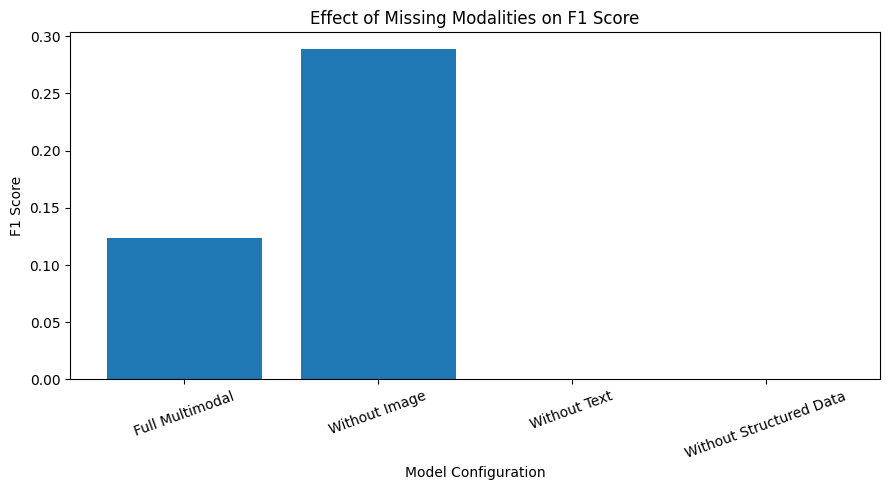

In [13]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    ablation_results[
        'Configuration'
    ],
    ablation_results[
        'F1'
    ]
)

plt.ylabel(
    'F1 Score'
)

plt.xlabel(
    'Model Configuration'
)

plt.title(
    'Effect of Missing Modalities on F1 Score'
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()

In [14]:
print(
    "MODALITY ABLATION SUMMARY"
)
for _, row in ablation_results.iterrows():

    print(
        f"{row['Configuration']}: "
        f"Accuracy={row['Accuracy']:.4f}, "
        f"F1={row['F1']:.4f}, "
        f"ROC-AUC={row['ROC-AUC']:.4f}"
    )

MODALITY ABLATION SUMMARY
Full Multimodal: Accuracy=0.7118, F1=0.1239, ROC-AUC=0.6736
Without Image: Accuracy=0.7278, F1=0.2890, ROC-AUC=0.6833
Without Text: Accuracy=0.7147, F1=0.0000, ROC-AUC=0.6071
Without Structured Data: Accuracy=0.7147, F1=0.0000, ROC-AUC=0.5159


In [15]:
# performance drop
ablation_only = (
    ablation_results[
        ablation_results[
            'Configuration'
        ] != 'Full Multimodal'
    ]
)

worst_case = (
    ablation_only
    .sort_values(
        'F1 Change'
    )
    .iloc[0]
)

print(
    "Largest F1 reduction:"
)

print(
    worst_case[
        'Configuration'
    ]
)

print(
    "F1 change:",
    round(
        worst_case[
            'F1 Change'
        ],
        4
    )
)

Largest F1 reduction:
Without Text
F1 change: -0.1239


In [16]:
print(
    "FINAL MODALITY ABLATION RESULTS"
)
display(
    ablation_results[
        [
            'Configuration',
            'Accuracy',
            'F1',
            'ROC-AUC',
            'Accuracy Change',
            'F1 Change'
        ]
    ]
)

FINAL MODALITY ABLATION RESULTS


,Configuration,Accuracy,F1,ROC-AUC,Accuracy Change,F1 Change
0,Full Multimodal,0.711790,0.123894,0.673573,0.000000,0.000000
1,Without Image,0.727802,0.288973,0.683258,0.016012,0.165080
2,Without Text,0.714702,0.000000,0.607060,0.002911,-0.123894
3,Without Structured Data,0.714702,0.000000,0.515909,0.002911,-0.123894
